# TT-21 — KNN Regressor: Định giá nhà theo "các căn tương tự trong khu vực"


In [1]:
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

RANDOM_STATE = 42
def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

## 1. Nạp dữ liệu

In [2]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Xử lý outlier AveOccup / AveRooms trên tập train
mask = (X_train["AveOccup"] < 10) & (X_train["AveRooms"] < 20)
print(f"Loại {(~mask).sum()} dòng outlier khỏi train")
X_train = X_train[mask]
y_train = y_train.loc[X_train.index]

X.describe()

Loại 92 dòng outlier khỏi train


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


## 2. Baseline: Dummy + Linear Regression

In [3]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
lin = LinearRegression().fit(X_train, y_train)

rmse_dummy = rmse(y_test, dummy.predict(X_test))
rmse_lin = rmse(y_test, lin.predict(X_test))
r2_lin = r2_score(y_test, lin.predict(X_test))

print(f"Dummy RMSE:  {rmse_dummy:.4f}")
print(f"Linear RMSE: {rmse_lin:.4f}  (R2={r2_lin:.4f})")

Dummy RMSE:  1.1449
Linear RMSE: 0.8906  (R2=0.3947)


## 3. KNN KHÔNG chuẩn hoá — vì sao rất tệ

`Population` có giá trị hàng nghìn trong khi `Latitude` chỉ 32–42.
Khoảng cách Euclidean sẽ gần như chỉ phụ thuộc vào `Population`.

In [4]:
knn_noscale = KNeighborsRegressor(n_neighbors=5, n_jobs=-1).fit(X_train, y_train)
rmse_noscale = rmse(y_test, knn_noscale.predict(X_test))
print(f"KNN KHÔNG scale, K=5: RMSE={rmse_noscale:.4f}  (so với Linear={rmse_lin:.4f})")

KNN KHÔNG scale, K=5: RMSE=1.0582  (so với Linear=0.8906)


## 4. KNN có chuẩn hoá (Pipeline đúng cách)

In [5]:
pipe_default = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance", n_jobs=-1)),
]).fit(X_train, y_train)

rmse_scaled = rmse(y_test, pipe_default.predict(X_test))
print(f"KNN có scale, K=5, weights=distance: RMSE={rmse_scaled:.4f}")

KNN có scale, K=5, weights=distance: RMSE=0.6032


## 5. RMSE train/test theo K = 1..50

**Lưu ý về K=1:** khi K=1, một điểm train được dự đoán bằng chính nó
(khoảng cách=0) → train RMSE ≈ 0. Với `weights='distance'`, hiệu ứng này còn
xảy ra ở MỌI K vì hàng xóm khoảng-cách-0 (chính nó) luôn được gán trọng số
gần như tuyệt đối. Đây là lý do không bao giờ được chọn K dựa vào train RMSE.

K tối ưu theo test RMSE = 22  (test RMSE=0.5899)


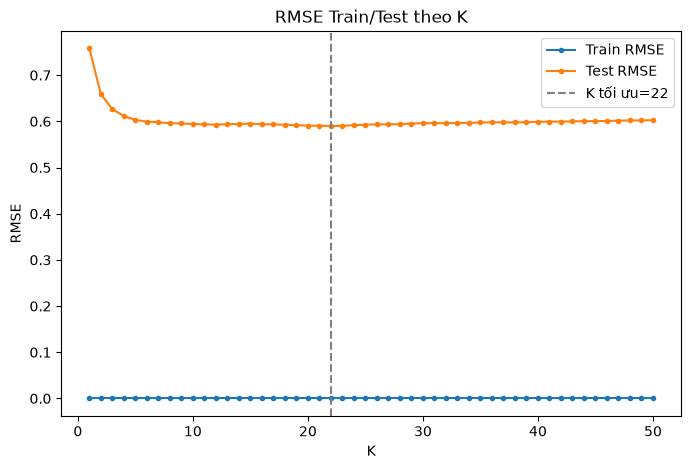

In [6]:
K_range = range(1, 51)
train_rmse, test_rmse = [], []
for k in K_range:
    p = Pipeline([("scale", StandardScaler()),
                  ("knn", KNeighborsRegressor(n_neighbors=k, weights="distance", n_jobs=-1))])
    p.fit(X_train, y_train)
    train_rmse.append(rmse(y_train, p.predict(X_train)))
    test_rmse.append(rmse(y_test, p.predict(X_test)))

best_k = list(K_range)[int(np.argmin(test_rmse))]
print(f"K tối ưu theo test RMSE = {best_k}  (test RMSE={min(test_rmse):.4f})")

plt.figure(figsize=(8,5))
plt.plot(list(K_range), train_rmse, label="Train RMSE", marker=".")
plt.plot(list(K_range), test_rmse, label="Test RMSE", marker=".")
plt.axvline(best_k, color="gray", linestyle="--", label=f"K tối ưu={best_k}")
plt.xlabel("K"); plt.ylabel("RMSE"); plt.legend()
plt.title("RMSE Train/Test theo K")
plt.show()

## 6–7. So sánh weights (uniform vs distance) và metric (euclidean vs manhattan)

In [7]:
for w in ["uniform", "distance"]:
    p = Pipeline([("scale", StandardScaler()),
                  ("knn", KNeighborsRegressor(n_neighbors=best_k, weights=w, n_jobs=-1))]).fit(X_train, y_train)
    print(f"weights={w:9s} RMSE={rmse(y_test, p.predict(X_test)):.4f}")

for m in ["euclidean", "manhattan"]:
    p = Pipeline([("scale", StandardScaler()),
                  ("knn", KNeighborsRegressor(n_neighbors=best_k, weights="distance", metric=m, n_jobs=-1))]).fit(X_train, y_train)
    print(f"metric={m:10s} RMSE={rmse(y_test, p.predict(X_test)):.4f}")

weights=uniform   RMSE=0.5936
weights=distance  RMSE=0.5899
metric=euclidean  RMSE=0.5899
metric=manhattan  RMSE=0.5674


## 8. Thí nghiệm trọng số vị trí 

Nhân Latitude/Longitude (sau khi scale) với hệ số {1,2,3,5} để ép KNN ưu tiên
tìm hàng xóm địa lý gần trước.

Hệ số x1: RMSE=0.5899
Hệ số x2: RMSE=0.5550
Hệ số x3: RMSE=0.5339
Hệ số x5: RMSE=0.5091


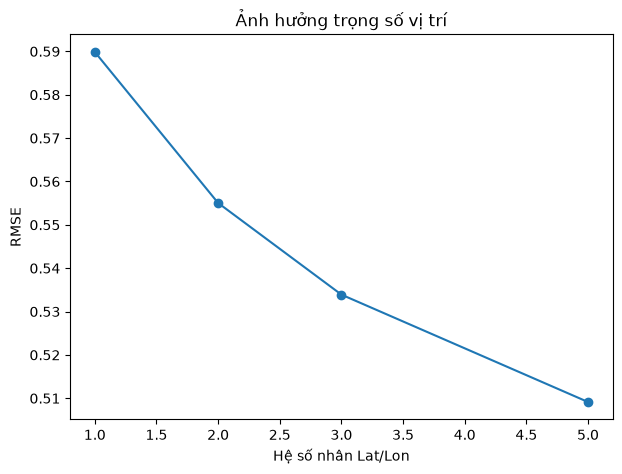


=> Kết luận: RMSE giảm liên tục khi tăng trọng số vị trí trong khoảng thử nghiệm (1->5), khẳng định vị trí là yếu tố quan trọng nhất trong định giá nhà ở bộ dữ liệu này — đúng với trực giác thẩm định BĐS thực tế.


In [8]:
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

he_so_list = [1, 2, 3, 5]
rmses_loc = []
for he_so in he_so_list:
    Xtr = X_train_s.copy(); Xte = X_test_s.copy()
    Xtr[["Latitude","Longitude"]] *= he_so
    Xte[["Latitude","Longitude"]] *= he_so
    knn = KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1).fit(Xtr, y_train)
    r = rmse(y_test, knn.predict(Xte))
    rmses_loc.append(r)
    print(f"Hệ số x{he_so}: RMSE={r:.4f}")

plt.figure(figsize=(7,5))
plt.plot(he_so_list, rmses_loc, marker="o")
plt.xlabel("Hệ số nhân Lat/Lon"); plt.ylabel("RMSE")
plt.title("Ảnh hưởng trọng số vị trí")
plt.show()

print("\n=> Kết luận: RMSE giảm liên tục khi tăng trọng số vị trí trong khoảng thử "
      "nghiệm (1->5), khẳng định vị trí là yếu tố quan trọng nhất trong định giá nhà "
      "ở bộ dữ liệu này — đúng với trực giác thẩm định BĐS thực tế.")

## 9. Ví dụ: in ra 5 "căn tương tự" cho 3 căn nhà bất kỳ 

In [9]:
final_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1)),
]).fit(X_train, y_train)

X_test_scaled = final_pipe["scale"].transform(X_test)

for i in [0, 50, 100]:
    dist, idx = final_pipe["knn"].kneighbors(X_test_scaled[[i]], n_neighbors=5)
    print(f"\n=== Căn cần định giá (test idx={i}), giá thực={y_test.iloc[i]:.3f} ===")
    similar = X_train.iloc[idx[0]].assign(Gia=y_train.iloc[idx[0]].values, Khoang_cach=dist[0])
    print(similar)


=== Căn cần định giá (test idx=0), giá thực=0.477 ===
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20005  2.0586      28.0  4.509434   1.037736      1434.0  3.865229     36.13   
20002  1.7432      30.0  4.120448   1.044818      1418.0  3.971989     36.10   
19860  2.3304      24.0  4.524390   1.014634      1520.0  3.707317     36.35   
2883   1.4146      22.0  4.314286   1.088095      1592.0  3.790476     35.39   
20010  1.6452      32.0  4.324706   1.037647      1628.0  3.830588     36.06   

       Longitude    Gia  Khoang_cach  
20005    -119.13  0.409     0.399542  
20002    -119.21  0.425     0.448336  
19860    -119.30  0.649     0.531641  
2883     -118.98  0.491     0.584131  
20010    -119.14  0.415     0.613066  

=== Căn cần định giá (test idx=50), giá thực=2.519 ===
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
19299  4.4357      16.0  6.028571   1.042857       793.0  2.832143     38.39   
19315  4.6705 

## 10. Bảng so sánh Linear vs KNN vs RandomForest

In [10]:
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
models = {"Linear": lin, "KNN": final_pipe, "RandomForest": rf}

rows = []
for name, m in models.items():
    t0 = time.time(); m.fit(X_train, y_train); train_time = time.time() - t0
    t0 = time.time(); preds = m.predict(X_test); predict_ms = (time.time()-t0)/len(X_test)*1000
    rows.append({
        "Model": name,
        "RMSE": round(rmse(y_test, preds), 4),
        "R2": round(r2_score(y_test, preds), 4),
        "Train time (s)": round(train_time, 3),
        "Predict time (ms/mẫu)": round(predict_ms, 5),
    })

pd.DataFrame(rows)

,Model,RMSE,R2,Train time (s),Predict time (ms/mẫu)
0,Linear,0.8906,0.3947,0.006,0.00049
1,KNN,0.5899,0.7345,0.031,0.05717
2,RandomForest,0.5022,0.8076,2.090,0.01874


## 11. Thời gian dự đoán khi train tăng 1x / 5x / 10x

Train x1 (16420 dòng): predict/mẫu = 0.0460 ms
Train x5 (82100 dòng): predict/mẫu = 0.0650 ms
Train x10 (164200 dòng): predict/mẫu = 0.0499 ms


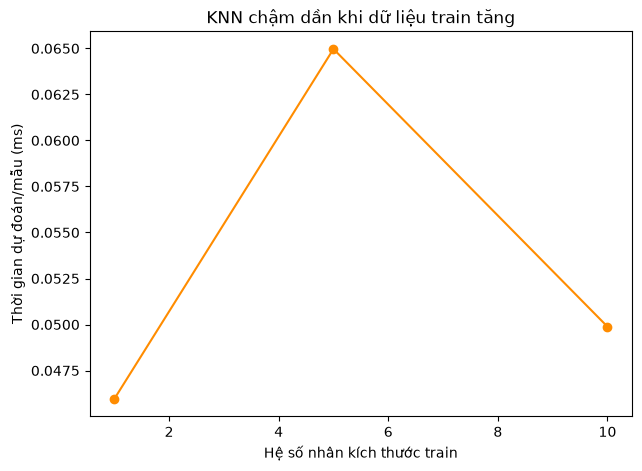

In [11]:
factors = [1, 5, 10]
times = []
for f in factors:
    X_big = pd.concat([X_train]*f, ignore_index=True)
    y_big = pd.concat([y_train]*f, ignore_index=True)
    p = Pipeline([("scale", StandardScaler()),
                  ("knn", KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1))]).fit(X_big, y_big)
    t0 = time.time(); p.predict(X_test); elapsed = (time.time()-t0)/len(X_test)*1000
    times.append(elapsed)
    print(f"Train x{f} ({len(X_big)} dòng): predict/mẫu = {elapsed:.4f} ms")

plt.figure(figsize=(7,5))
plt.plot(factors, times, marker="o", color="darkorange")
plt.xlabel("Hệ số nhân kích thước train"); plt.ylabel("Thời gian dự đoán/mẫu (ms)")
plt.title("KNN chậm dần khi dữ liệu train tăng")
plt.show()

## Lưu model cuối cùng

In [12]:
Path("../models").mkdir(exist_ok=True)
joblib.dump(final_pipe, "../models/knn_pipeline.joblib")
print("Đã lưu models/knn_pipeline.joblib")

Đã lưu models/knn_pipeline.joblib
